In [1]:
!python --version

Python 3.13.9


In [2]:
# Import necessary libraries
import os
from dotenv import load_dotenv
import google.generativeai as genai

# Load environment variables from .env file
load_dotenv()

# Configure the API key
api_key = os.getenv('GOOGLE_API_KEY')

if not api_key:
    raise ValueError(
        "GOOGLE_API_KEY not found. Please check your .env file."
    )

genai.configure(api_key=api_key)

print("✓ Google Gemini API configured successfully!")

✓ Google Gemini API configured successfully!


/Users/markgewhite/Documents/MyFiles/Projects/training/ztm/llm_web_apps/meal_plan/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def create_meals(ingredients, 
                 kcal=2000, 
                 exact_ingredients=False,
                 output_format='text', 
                 model='gemini-2.5-flash',
                 system_role='You are a skilled chef with expertise in cooking healthy meals.',
                 temperature=1,
                 extra=None):
    """
    Generate a daily meal plan using Google's Gemini AI.
    
    Parameters:
    - ingredients: List or string of available ingredients
    - kcal: Daily calorie limit (default 2000)
    - exact_ingredients: If True, use only provided ingredients
    - output_format: Format for output (text, markdown, etc.)
    - model: Gemini model to use (default: gemini-2.5-flash)
    - system_role: System instruction for the AI
    - temperature: Creativity level (0-2, default 1)
    - extra: Additional meal requirements
    
    Returns:
    - Text response with meal plan
    """
    
    # Construct the prompt
    prompt = f'''
    Create a healthy daily meal plan for breakfast lunch and dinner based on the following ingredients:
    ```{ingredients}```
    Your output should be in the {output_format} format.
    Follow the instructions below carefully.
    ### Instructions:
    1. {'Use ONLY the provided ingredients with salt, pepper and spices.' if exact_ingredients 
            else 'Feel free to adjust the provided ingredients as required for the meal.'}
    2. Specify the exact amount of each ingredient.
    3. Ensure the total daily calorie intake is below {kcal}.
    4. For each meal, explain each recipe step-by-step in clear and simple sentences. Use bullet points or numbers as appropriate.
    5. For each meal, specify the total number of calories and the number of servings.
    6. For each meal, provide a concise and descriptive title that summarises the main ingredients and flavours. The title should be sufficiently detailed for image generation to create an attractive image of the meal.
    7. For each recipe, indicate the preparation cooking and total time.
    {'8. If possible, the meals should be: ' + extra if extra else ''}
    
    Before answering, make sure that you have followed the instructions listed above.
    The last line of your answer should be a string that contains ONLY the titles of the recipes and nothing more. Separate the titles using a semi-colon.
    '''
    
    # Initialize the Gemini model with system instruction
    gemini_model = genai.GenerativeModel(
        model_name=model,
        system_instruction=system_role
    )
    
    # Generate content with specified temperature
    response = gemini_model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(
            temperature=temperature,
        )
    )
    
    # Return the text response
    return response.text

In [4]:
# List available models
print("Available Gemini models:\n")
for model in genai.list_models():
    if 'generateContent' in model.supported_generation_methods:
        print(f"• {model.name}")
        print(f"  Display name: {model.display_name}")
        print(f"  Description: {model.description}")
        print()

Available Gemini models:

• models/gemini-2.5-pro-vtea-da-csi
  Display name: Gemini 2.5 Pro Preview with VTEA and DA CSI
  Description: Preview release (Nov 25th, 2025) of Gemini 2.5 Pro with VTEA and DA CSI

• models/gemini-2.5-pro-preview-03-25
  Display name: Gemini 2.5 Pro Preview 03-25
  Description: Gemini 2.5 Pro Preview 03-25

• models/gemini-2.5-flash
  Display name: Gemini 2.5 Flash
  Description: Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.

• models/gemini-2.5-pro-preview-05-06
  Display name: Gemini 2.5 Pro Preview 05-06
  Description: Preview release (May 6th, 2025) of Gemini 2.5 Pro

• models/gemini-2.5-pro-preview-06-05
  Display name: Gemini 2.5 Pro Preview
  Description: Preview release (June 5th, 2025) of Gemini 2.5 Pro

• models/gemini-2.5-pro
  Display name: Gemini 2.5 Pro
  Description: Stable release (June 17th, 2025) of Gemini 2.5 Pro

• models/gemini-2.0-flash-exp
  Display na

In [5]:
# Test the create_meals function
ingredients = """
- Chicken breast
- Broccoli
- Rice
- Eggs
- Tomatoes
- Onions
- Garlic
- Olive oil
"""

# Generate meal plan
meal_plan = create_meals(
    ingredients=ingredients,
    kcal=2000,
    exact_ingredients=False,
    output_format='markdown',
    temperature=0.8,
    extra='high in protein'
)

print(meal_plan)

Here is a healthy daily meal plan designed to be high in protein and stay under 2000 total daily calories, using your specified ingredients.

---

### **Breakfast: Vibrant Savory Scrambled Eggs with Golden Sautéed Onions and Diced Red Tomatoes**

This protein-rich breakfast combines fluffy scrambled eggs with the sweetness of sautéed onions and the fresh tang of tomatoes, enhanced with a hint of garlic.

*   **Servings:** 1
*   **Preparation Time:** 5 minutes
*   **Cooking Time:** 5-7 minutes
*   **Total Time:** 10-12 minutes
*   **Total Calories:** Approximately 231 calories

**Ingredients:**

*   **2 Large Eggs:** 160 calories
*   **30g (approx. 1/4 medium) Onion,** finely diced: 12 calories
*   **60g (approx. 1/2 medium) Tomato,** diced: 11 calories
*   **2g (approx. 1 small clove) Garlic,** minced: 3 calories
*   **5ml (1 teaspoon) Olive Oil:** 45 calories
*   Salt and black pepper, to taste (negligible calories)

**Recipe Steps:**

1.  Heat the olive oil in a non-stick pan over me

In [6]:
def extract_meal_titles(meal_plan_text):
    """
    Extract individual meal titles from the meal plan response.
    
    The meal plan text should have the titles on the last line,
    separated by commas as per the prompt instructions.
    
    Parameters:
    - meal_plan_text: The full text response from create_meals()
    
    Returns:
    - List of meal titles (typically 3: breakfast, lunch, dinner)
    """
    # Get the last line which contains only the meal titles
    lines = meal_plan_text.strip().split('\n')
    last_line = lines[-1].strip()
    
    # Split by comma to get individual titles
    titles = [title.strip() for title in last_line.split(';')]
    
    return titles


# Test it with our meal plan
titles = extract_meal_titles(meal_plan)

print("Extracted Meal Titles:")
print("=" * 60)
for i, title in enumerate(titles, 1):
    print(f"{i}. {title}")
print("=" * 60)
print(f"\nTotal meals: {len(titles)}")

Extracted Meal Titles:
1. Vibrant Savory Scrambled Eggs with Golden Sautéed Onions and Diced Red Tomatoes
2. Perfectly Grilled Lean Chicken Breast with Bright Green Steamed Broccoli and Fluffy White Rice
3. Hearty Chicken and Broccoli Stir-fry in a Rich Garlic Tomato Sauce with Steamed White Rice

Total meals: 3


In [7]:
from PIL import Image
import io

def generate_meal_images(meal_titles, model='gemini-2.5-flash-image'):
    """
    Generate images for each meal using Google's image generation models.
    
    Parameters:
    - meal_titles: List of meal title strings
    - model: Image generation model (default: gemini-2.5-flash-image)
            Options: 'gemini-2.5-flash-image', 'nano-banana-pro-preview'
    
    Returns:
    - List of PIL Image objects
    """
    images = []
    
    print(f"Generating images using {model}...")
    print("=" * 60)
    
    for i, title in enumerate(meal_titles, 1):
        print(f"\nImage {i}/{len(meal_titles)}: {title[:50]}...")
        
        try:
            # Create a descriptive prompt
            prompt = f"Generate a professional food photography image of: {title}. Make it appetizing, well-plated, high quality, restaurant style."
            
            # Initialize model and generate
            image_model = genai.GenerativeModel(model_name=model)
            response = image_model.generate_content(
                prompt,
                generation_config=genai.GenerationConfig(temperature=0.4),
                request_options={"timeout": 60}
            )
            
            # Extract images from response parts
            if hasattr(response, 'parts') and response.parts:
                for part_idx, part in enumerate(response.parts):
                    # Check if this part contains image data
                    if hasattr(part, 'inline_data') and part.inline_data:
                        # Get the image bytes
                        image_data = part.inline_data.data
                        mime_type = part.inline_data.mime_type
                        
                        print(f"  Found image data (type: {mime_type}, size: {len(image_data)} bytes)")
                        
                        # Convert to PIL Image
                        pil_image = Image.open(io.BytesIO(image_data))
                        images.append(pil_image)
                        print(f"  ✓ Image {i} generated successfully! ({pil_image.size[0]}x{pil_image.size[1]})")
                        break  # Only take the first image
                    elif hasattr(part, 'text') and part.text:
                        print(f"  Part {part_idx} contains text: {part.text[:100]}...")
            else:
                print(f"  ⚠ No image data in response")
                
        except Exception as e:
            print(f"  ✗ Error: {type(e).__name__}: {e}")
    
    print("=" * 60)
    print(f"\n✓ Generated {len(images)} out of {len(meal_titles)} images")
    
    return images

In [8]:
# First, let's check what image generation capabilities are available
print("Checking image generation API...")
print("\nAvailable attributes in genai module:")
print([attr for attr in dir(genai) if 'image' in attr.lower() or 'Image' in attr])

# Let's also check if we can use GenerativeModel for images
print("\n\nLet's try to explore the Nano Banana Pro model:")
try:
    model_info = genai.get_model('models/nano-banana-pro-preview')
    print(f"Model: {model_info.name}")
    print(f"Supported methods: {model_info.supported_generation_methods}")
except Exception as e:
    print(f"Error: {e}")

Checking image generation API...

Available attributes in genai module:
[]


Let's try to explore the Nano Banana Pro model:
Model: models/nano-banana-pro-preview
Supported methods: ['generateContent', 'countTokens', 'batchGenerateContent']


In [9]:
# Generate images for all 3 meals
meal_images = generate_meal_images(titles)

Generating images using gemini-2.5-flash-image...

Image 1/3: Vibrant Savory Scrambled Eggs with Golden Sautéed ...
  Part 0 contains text: Here is a professional food photography image of vibrant savory scrambled eggs with golden sautéed o...
  Found image data (type: image/png, size: 1506025 bytes)
  ✓ Image 1 generated successfully! (1024x1024)

Image 2/3: Perfectly Grilled Lean Chicken Breast with Bright ...
  Part 0 contains text: Here is your professional food photography image: ...
  Found image data (type: image/png, size: 1506305 bytes)
  ✓ Image 2 generated successfully! (1024x1024)

Image 3/3: Hearty Chicken and Broccoli Stir-fry in a Rich Gar...
  Part 0 contains text: Here is a professional food photography image of a hearty chicken and broccoli stir-fry in a rich ga...
  Found image data (type: image/png, size: 1607858 bytes)
  ✓ Image 3 generated successfully! (1024x1024)

✓ Generated 3 out of 3 images


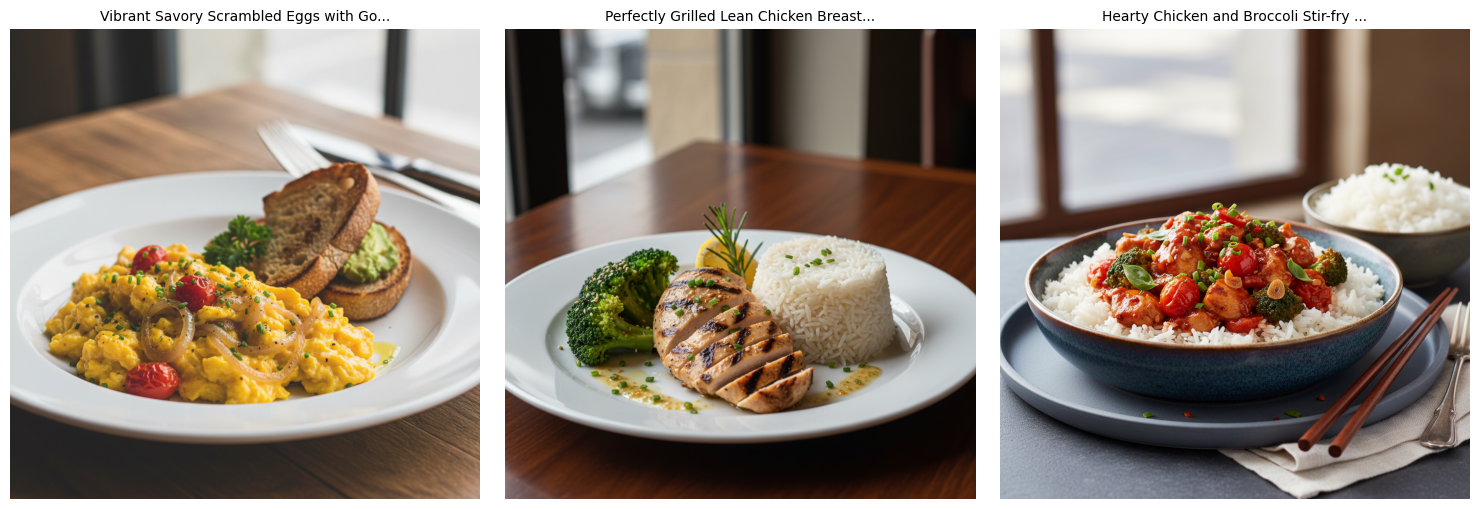


✓ Displayed 3 meal images!


In [10]:
# Display the generated images
import matplotlib.pyplot as plt

if meal_images:
    # Create a figure with subplots for each meal
    fig, axes = plt.subplots(1, len(meal_images), figsize=(15, 5))
    
    # Handle case of single image
    if len(meal_images) == 1:
        axes = [axes]
    
    for idx, (img, title) in enumerate(zip(meal_images, titles)):
        axes[idx].imshow(img)
        axes[idx].axis('off')
        # Truncate title if too long
        short_title = title if len(title) <= 40 else title[:37] + "..."
        axes[idx].set_title(short_title, fontsize=10, wrap=True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Displayed {len(meal_images)} meal images!")
else:
    print("No images to display.")